# Testing hardware controls in ALS optics lab
awojdyla@lbl.gov, dec 2025

We want to control some hardware to perform experiments:
- a camera (basler, ethernet connection)
- three stages (throlabs apt)

In [3]:
#!pip install pylablib
#!pip install pypylon

## testing stage controls

In [7]:
from pylablib.devices.Thorlabs import KinesisMotor

# Connect to the Thorlabs APT device
# Replace 'COM3' with your actual serial port or device ID
motor = KinesisMotor("COM3")

# Get device information
print(f"Device: {motor.get_device_info()}")

ThorlabsBackendError: backend exception: SerialException(2, "could not open port COM3: [Errno 2] No such file or directory: 'COM3'") ('[Errno 2] could not open port COM3: [Errno 2] No such file or directory: 'COM3'')

In [20]:
from pylablib.devices import Thorlabs
from pylablib.devices.Thorlabs import KinesisMotor

# List all available Thorlabs Kinesis devices without opening a port
available_devices = Thorlabs.list_kinesis_devices()
print(available_devices)

# Connect only if a device is found
if available_devices:
	port = available_devices[0].get("port", "/dev/ttyUSB0")
	my_motor = KinesisMotor(port)
	print("Connected to:", port)

AttributeError: module 'pylablib.core.devio.comm_backend' has no attribute 'FT232DeviceBackend'

In [21]:
from pylablib.devices import Thorlabs

# Use the device file name as the connection parameter
# Replace "/dev/ttyUSB0" with your actual device file
stage = Thorlabs.KinesisMotor("/dev/ttyUSB0")

# Example commands:
stage.home() # Home the stage
stage.move_to(10.0) # Move to a specific position (e.g., 10 mm)
position = stage.get_position() # Get the current position

stage.close() # Close the connection

ThorlabsBackendError: backend exception: 'read returned less than expected: 0 instead of 1' ('read returned less than expected: 0 instead of 1')

In [ ]:
#!pip install --user --upgrade thorlabs-apt-device

In [32]:
from thorlabs_apt_device import APTDevice
import thorlabs_apt_device

device = thorlabs_apt_device.devices.aptdevice_motor.APTDevice_Motor("/dev/ttyUSB1")
#device.home() # Home the stage
#device.move_relative(10) # Move to a specific position (e.g., 10 mm)
device.status_



[[{'position': 0,
   'enc_count': 0,
   'velocity': 0.0,
   'forward_limit_switch': False,
   'reverse_limit_switch': False,
   'moving_forward': False,
   'moving_reverse': False,
   'jogging_forward': False,
   'jogging_reverse': False,
   'motor_connected': False,
   'homing': True,
   'homed': False,
   'tracking': False,
   'interlock': False,
   'settled': False,
   'motion_error': False,
   'motor_current_limit_reached': False,
   'channel_enabled': False,
   'msg': '',
   'msgid': 0,
   'source': 0,
   'dest': 0,
   'chan_ident': 0}]]

Exception in callback APTDevice._schedule_reads()
handle: <TimerHandle when=667.357848156 APTDevice._schedule_reads()>
Traceback (most recent call last):
  File "/home/dreambeam/miniconda3/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dreambeam/.local/lib/python3.13/site-packages/thorlabs_apt_device/devices/aptdevice.py", line 226, in _schedule_reads
    for msg in self._unpacker:
               ^^^^^^^^^^^^^^
  File "/home/dreambeam/.local/lib/python3.13/site-packages/thorlabs_apt_device/protocol/unpacker.py", line 81, in __next__
    self.buf += self._file.read(6 - len(self.buf))
                ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/home/dreambeam/miniconda3/lib/python3.13/site-packages/serial/serialposix.py", line 595, in read
    raise SerialException(
        'device reports readiness to read but returned no data '
        '(device disconnected or multipl

In [33]:
device.status_

[[{'position': 0,
   'enc_count': 0,
   'velocity': 0.0,
   'forward_limit_switch': False,
   'reverse_limit_switch': False,
   'moving_forward': False,
   'moving_reverse': False,
   'jogging_forward': False,
   'jogging_reverse': False,
   'motor_connected': False,
   'homing': True,
   'homed': False,
   'tracking': False,
   'interlock': False,
   'settled': False,
   'motion_error': False,
   'motor_current_limit_reached': False,
   'channel_enabled': False,
   'msg': '',
   'msgid': 0,
   'source': 0,
   'dest': 0,
   'chan_ident': 0}]]

In [1]:
import thorlabs_apt_device

## Testing camera controls

In [3]:
from pypylon import pylon

# Create an instant camera object with the camera device found first.
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())
# Print the model name of the camera.
print("Using device ", camera.GetDeviceInfo().GetModelName())

Using device  acA1920-25gc


In [4]:
# Capture a single image from the camera
camera.StartGrabbingMax(1)
converter = pylon.ImageFormatConverter()
converter.OutputPixelFormat = pylon.PixelType_RGB8packed
converter.OutputBitAlignment = pylon.OutputBitAlignment_MsbAligned

grab_result = camera.RetrieveResult(5000, pylon.TimeoutHandling_ThrowException)
if grab_result.GrabSucceeded():
    image = converter.Convert(grab_result)
    frame = image.GetArray()
    print("Captured frame shape:", frame.shape)
else:
    print("Failed to grab image")
grab_result.Release()
camera.StopGrabbing()

Captured frame shape: (1080, 1920, 3)


In [11]:
camera.Close()

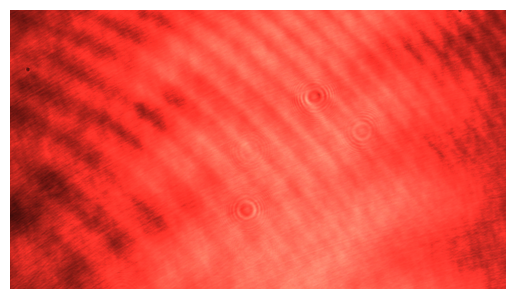

In [6]:
import matplotlib.pyplot as plt
plt.imshow(frame)
plt.axis('off')
plt.show()  


In [9]:
devices = pylon.TlFactory.GetInstance().EnumerateDevices()
for dev in devices:
    info = dev.GetModelName()
    serial = dev.GetSerialNumber()
    print(f"Model: {info}, Serial: {serial}")

Model: acA1920-25gc, Serial: 24452081
Model: a2A1920-51gcBAS, Serial: 40493160


In [ ]:
from pypylon import pylon

# Connect to a camera by its IP address
ip_address = "192.168.10.210"  # replace with your camera's IP
device_info = pylon.DeviceInfo().SetIpAddress(ip_address)
ip_camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateDevice(device_info))
#print("Connected to:", ip_camera.GetDeviceInfo().GetModelName(), "| Serial:", ip_camera.GetDeviceInfo().GetSerialNumber())

: 

In [2]:
from pypylon import pylon 
info = pylon.TlFactory.GetInstance().EnumerateDevices()[1] # Get info for the first device
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateDevice(info))
print(info.GetModelName(), info.GetSerialNumber())

a2A1920-51gcBAS 40493160
